# HR Attrition — Feature Engineering & Modeling

Building on EDA findings: OverTime is the strongest signal, income shows a gradient, and attrition concentrates in Sales Rep role.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.shape

(1470, 35)

## 1. Drop columns that can't help or that leak

Before encoding anything, remove:
- Constant columns (same value for every row — carry zero information)
- ID-like columns (unique per row — a model could 'memorize' the ID instead of learning a pattern)
- Anything that is a direct proxy for the outcome (true leakage)

In [3]:
# Check for constant columns first (info you should always check, not assume)
for col in df.columns:
    if df[col].nunique() == 1:
        print(f'Constant column: {col} = {df[col].unique()}')

Constant column: EmployeeCount = [1]
Constant column: Over18 = ['Y']
Constant column: StandardHours = [80]


In [4]:
# EmployeeCount, StandardHours, Over18 are known constants in this dataset
# EmployeeNumber is a unique ID -- drop all of these, they add no predictive value
drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df = df.drop(columns=drop_cols)
df.shape

(1470, 31)

## 2. Encode the target and categorical features

Models need numbers, not text. Two encoding strategies:
- **Binary columns** (Attrition, OverTime, Gender): map Yes/No -> 1/0 directly
- **Multi-category columns** (Department, JobRole, etc.): one-hot encode, so the model doesn't
  wrongly assume an order (e.g. Sales < R&D < HR would be nonsense if label-encoded as 0,1,2)

In [5]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.shape

(1470, 45)

## 3. Train/test split

Split BEFORE any further processing that 'looks at' the target, so nothing about the test set
leaks into how you build the model. `stratify=y` keeps the same 84/16 class ratio in both splits --
important given the imbalance found in EDA.

In [8]:
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print('Train attrition rate:', y_train.mean().round(3))
print('Test attrition rate:', y_test.mean().round(3))

(1176, 44) (294, 44)
Train attrition rate: 0.162
Test attrition rate: 0.16


## 4. Baseline model: Logistic Regression

`class_weight='balanced'` tells the model to penalize mistakes on the minority class (attrition=Yes)
more heavily -- without this, the model could just predict 'No' for everyone and still look
84% accurate, which would be useless.

In [15]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_lr), 3))

              precision    recall  f1-score   support

           0       0.92      0.71      0.80       247
           1       0.30      0.66      0.41        47

    accuracy                           0.70       294
   macro avg       0.61      0.68      0.61       294
weighted avg       0.82      0.70      0.74       294

ROC-AUC: 0.777


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Compare: Random Forest

In [13]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_rf), 3))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294

ROC-AUC: 0.783


## 6. Confusion matrices side by side

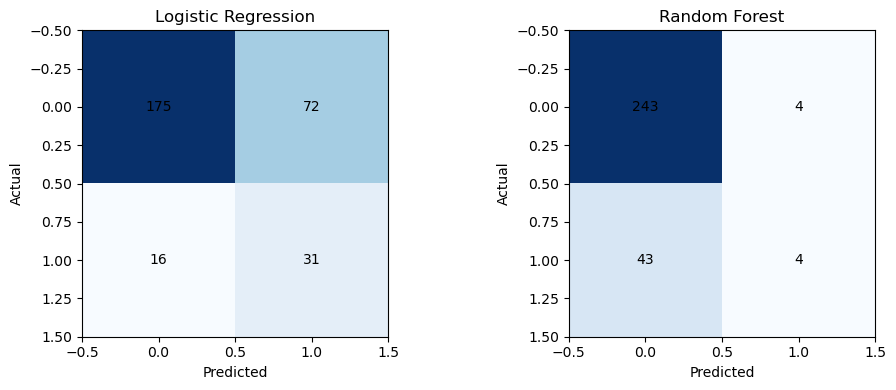

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, title in zip(axes, [y_pred_lr, y_pred_rf], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()

## 7. What actually drives the prediction? (interpretability)

Logistic Regression coefficients tell you direction and relative strength -- this is what you
point to when explaining findings to a non-technical stakeholder.

In [12]:
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
coefs.head(10)

OverTime                            0.536258
StockOptionLevel                   -0.394998
MaritalStatus_Single                0.324829
EnvironmentSatisfaction            -0.310679
Department_Sales                    0.246115
JobSatisfaction                    -0.244470
BusinessTravel_Travel_Frequently    0.236502
PerformanceRating                   0.210564
JobRole_Laboratory Technician       0.210466
JobInvolvement                     -0.178622
dtype: float64

## 8. Honest conclusion
- Both models rank attrition risk almost equally well (ROC-AUC 0.777 LR vs 0.783 RF) -- 
  the underlying signal in the data is comparable. The real difference is in each 
  model's default decision threshold, not its ability to detect risk.
- At default thresholds, Random Forest is too conservative for a retention use case: 
  it only flags 4 of 47 actual leavers (9% recall), even though its precision (50%) 
  is higher when it does flag someone. Logistic Regression flags more people overall, 
  catching 66% of actual leavers (31/47) at the cost of more false positives.
- For a retention tool, recall matters more than precision -- missing an at-risk 
  employee is more costly than one extra unnecessary conversation with HR. On that 
  basis, Logistic Regression is the more useful model as configured, though Random 
  Forest's threshold could likely be adjusted (e.g. lowering the classification 
  cutoff) to close this gap -- a natural next step beyond this analysis.
- Top predictors align with EDA: OverTime is the single strongest driver of attrition. 
  New from modeling: low StockOptionLevel and being unmarried also increase risk.
- What HR can act on: overtime policy and stock option allocation are levers the 
  company controls. Marital status is a proxy worth noting, not something to build 
  policy around.